# Яндекс Книги: Москва и Санкт-Петербург + оценка A/B-теста интернет-магазина

Учебный проект программы «Аналитик данных» (Яндекс Практикум), выполнен самостоятельно. Состоит из двух частей: проверка гипотезы по данным Яндекс Книг и анализ A/B-теста нового интерфейса интернет-магазина.
Стек: Python, pandas, matplotlib, SciPy, statsmodels.

# Часть 1. Проверка гипотезы: Москва и Санкт-Петербург

## Цель и задачи

**Цель:** проверить гипотезу, что пользователи Яндекс Книг из Санкт-Петербурга в среднем проводят за чтением и прослушиванием больше времени, чем пользователи из Москвы.

**Что сделано:**
1. Загрузка данных, проверка пропусков, полных дубликатов и повторов пользователей.
2. Описательные статистики по городам.
3. Гипотезы $H_0$ и $H_1$, односторонний t-тест Уэлча, $\alpha = 0.05$.
4. Аналитическая записка: интерпретация и возможные причины результата.

## Данные

Учебный датасет Яндекс Практикума (`yandex_knigi_data.csv`, 8784 записи): город пользователя (Москва или Санкт-Петербург), идентификатор пользователя `puid` и суммарное время чтения и прослушивания в часах. Данные являются материалами курса и в репозиторий не входят.

## Содержание

1. Загрузка данных и знакомство с ними
2. Проверка гипотезы
3. Аналитическая записка
4. Часть 2: оценка A/B-теста интернет-магазина

---

## 1. Загрузка данных и знакомство с ними

In [1]:
import pandas as pd
df = pd.read_csv('data/yandex_knigi_data.csv')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [2]:
# Проверяем наличие пропусков
df.isna().sum()

Unnamed: 0    0
city          0
puid          0
hours         0
dtype: int64

In [3]:
# Изначальное кол-во строк
initial_count_row = len(df)

# 1. Полные дубликаты строк
duplicated_rows = df.duplicated().sum()

# 2. Дубликаты по идентификатору пользователя puid
duplicated_puids = df['puid'].duplicated().sum()

# 3. Дубликаты по идентифкатору пользователя удаляем
df = df.drop_duplicates(subset=['puid'])

# Финальное кол-во строк (после удаление дубликатов puid)
final_count_row = len(df)

print(f'Изначальное кол-во строк: {initial_count_row}')
print(f'Кол-во полных дубликатов: {duplicated_rows}')
print(f'Кол-во повторов puid: {duplicated_puids}')
print(f'Финальное кол-во строк: {final_count_row}')

Изначальное кол-во строк: 8784
Кол-во полных дубликатов: 0
Кол-во повторов puid: 244
Финальное кол-во строк: 8540


In [4]:
# Сравнение размера групп и их статистики
df_grouped = df.groupby('city').agg(
    total_users=('puid', 'nunique'),
    total_hours=('hours', 'sum')
).reset_index()

In [5]:
# Расчёт среднего показателя прослушивания в часах на 1-го пользователя в разрезе городов
df_grouped['avg_hours_user'] = df_grouped['total_hours'] / df_grouped['total_users']
df_grouped['avg_hours_user'] = df_grouped['avg_hours_user'].round(2)
df_grouped

,city,total_users,total_hours,avg_hours_user
0,Москва,6234,67832.727924,10.88
1,Санкт-Петербург,2306,25975.783344,11.26


## 2. Проверка гипотезы

Проверяем одностороннюю гипотезу для двух выборок:

**$H_0$:** средняя активность пользователей в Санкт-Петербурге не больше, чем в Москве ($\mu_{СПб} \le \mu_{Москва}$).

**$H_1$:** средняя активность пользователей в Санкт-Петербурге больше ($\mu_{СПб} > \mu_{Москва}$).

                  count       mean        std       min       25%       50%  \
city                                                                          
Москва           6234.0  10.881092  36.851683  0.000018  0.059903  0.924498   
Санкт-Петербург  2306.0  11.264433  39.831755  0.000025  0.060173  0.875355   

                      75%         max  
city                                   
Москва           5.939972  857.209373  
Санкт-Петербург  6.138424  978.764775  


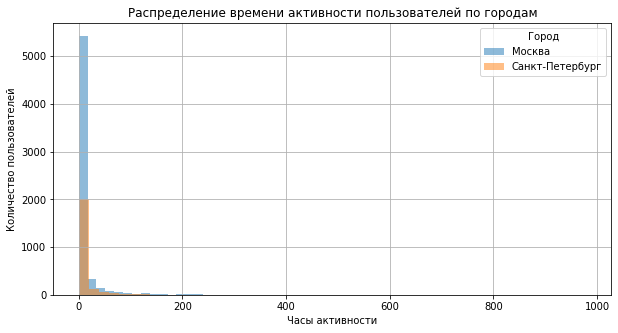

In [6]:
import matplotlib.pyplot as plt

# Сравнение описательных статистик
print(df.groupby('city')['hours'].describe())

# Визуализация распределения
plt.figure(figsize=(10, 5))

# Выделяем часы активности по городам
hours_msk = df[df['city'] == 'Москва']['hours']
hours_spb = df[df['city'] == 'Санкт-Петербург']['hours']

# Строим наложенные гистограммы
plt.hist(hours_msk, bins=50, alpha=0.5, label='Москва')
plt.hist(hours_spb, bins=50, alpha=0.5, label='Санкт-Петербург')

plt.title('Распределение времени активности пользователей по городам')
plt.xlabel('Часы активности')
plt.ylabel('Количество пользователей')
plt.legend(title='Город')
plt.grid(True)
plt.show()

In [7]:
from scipy.stats import ttest_ind

metric_spb = df[df.city=='Санкт-Петербург']['hours'] # Выборка целевой метрики для группы spb
metric_msk = df[df.city=='Москва']['hours'] # Выборка целевой метрики для группы msk

alpha = 0.05 # На каком уровне значимости проверяем гипотезу о равенстве выборочных средних

stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    metric_spb, 
    metric_msk, 
    equal_var=False,
    alternative='greater' # Проверяем, что СПб > Москва,
) # применяем t-тест Уэлча
if p_value_welch_ttest>alpha:
    print(f'p-value теста Уэлча = {round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение! Выборочные средние в группах'
      ' равны или в Москве больше.')
    print('Интерпретация: Среднее время активности пользователей в Санкт-Петербурге'
      ' не больше, чем в Москве.')
else:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза отвергается!')
    print('Интерпретация: Среднее время активности пользователей в Санкт-Петербурге'
      ' статистически значимо больше, чем в Москве.')

p-value теста Уэлча = 0.34
Нулевая гипотеза находит подтверждение! Выборочные средние в группах равны или в Москве больше.
Интерпретация: Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.


### 3. Аналитическая записка

#### 1. Тест и уровень значимости
* Двухвыборочный односторонний t-тест Уэлча (`scipy.stats.ttest_ind`, `equal_var=False`, `alternative='greater'`).
* Тест Уэлча выбран потому, что размеры групп сильно различаются (Москва — 6234 пользователя, Санкт-Петербург — 2306), а стандартные отклонения не равны (36,85 и 39,83).
* Уровень значимости $\alpha = 0.05$.

#### 2. Результаты
* **Москва:** среднее 10,88 ч, медиана 0,92 ч ($N = 6234$).
* **Санкт-Петербург:** среднее 11,26 ч, медиана 0,88 ч ($N = 2306$).
* **p-value:** 0,34.

#### 3. Вывод
* p-value (0,34) > $\alpha$ (0,05), оснований отвергнуть $H_0$ нет.
* Среднее в Санкт-Петербурге выше на 0,38 ч, но разница статистически незначима: если на самом деле разницы нет, такое или большее различие получалось бы примерно в 34% случаев.
* Данные не подтверждают гипотезу о том, что пользователи из Санкт-Петербурга проводят в приложении больше времени.

#### 4. Возможные причины
1. **Сильная асимметрия:** у половины пользователей в обоих городах меньше 1 часа активности (медианы 0,92 и 0,88 ч), а максимумы достигают 857 и 979 часов. Небольшая доля очень активных пользователей завышает среднее и увеличивает разброс, поэтому небольшая разница средних оказывается незначимой.
2. **Похожие сценарии использования (предположение):** в обоих городах-миллионниках сервисом, вероятно, пользуются в похожих ситуациях (транспорт, спорт, домашние дела), поэтому большой разницы в поведении нет. В данных это не проверялось.

----

# Часть 2. Оценка результатов A/B-теста интернет-магазина

### 1. Цели и задачи (тест `interface_eu_test`)

**Контекст:** интернет-магазин геймифицированных товаров для здорового образа жизни (BitMotion Kit) по отзывам пользователей считает интерфейс сайта слишком сложным. Разработана упрощённая версия сайта, её проверили A/B-тестом `interface_eu_test`.

**Цель:** оценить корректность теста и проверить, повышает ли новый интерфейс конверсию зарегистрированных пользователей в покупку в течение 7 дней после регистрации; ожидаемый эффект — не меньше 3 процентных пунктов.

**Что сделано:**
1. Загрузка данных об участниках тестов и событиях, проверка пропусков и дубликатов.
2. Проверка корректности: пересечения групп A и B, пересечение с параллельным тестом `recommender_system_test`, равномерность групп.
3. Отбор событий за 7 дней после регистрации, расчёт необходимого размера выборки, конверсии в группах.
4. Z-тест для долей и выводы для бизнеса.

## 2. Загрузка данных и проверка целостности

In [8]:
# Загрузка данных
participants = pd.read_csv('data/ab_test_participants.csv')
events = pd.read_csv('data/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [9]:
# Первичный анализ
participants.info()
participants.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [10]:
# Первичный анализ
events.info()
events.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [11]:
# Удаление полных дублей
participants = participants.drop_duplicates().reset_index(drop=True)
events = events.drop_duplicates().reset_index(drop=True)

In [12]:
participants.isna().sum()

user_id    0
group      0
ab_test    0
device     0
dtype: int64

In [13]:
events.isna().sum()

user_id            0
event_dt           0
event_name         0
details       506063
dtype: int64

## 3. Корректность проведения теста

In [14]:
# Выделяем пользователей целевого теста interface_eu_test
ab_test_participants = participants[participants['ab_test'] == 'interface_eu_test'].reset_index(drop=True)

In [15]:
# Проверка пересечений между группами A и B внутри interface_eu_test
group_a = ab_test_participants[ab_test_participants['group'] == 'A']['user_id']
group_b = ab_test_participants[ab_test_participants['group'] == 'B']['user_id']

intersection = list(set(group_a) & set(group_b))

if len(intersection) == 0:
    print("Пересечений между группами A и B не обнаружено")
else:
    print("Пользователи в обеих группах:", intersection)

Пересечений между группами A и B не обнаружено


In [16]:
# Проверка пересечения с конкурирующим тестом recommender_system_test
rec_test_participants = participants[participants['ab_test'] == 'recommender_system_test']['user_id']

intersection = list(
    set(ab_test_participants['user_id']) & set(rec_test_participants)
)

if len(intersection) == 0:
    print("Пересечений между конкурирующим тестом recommender_system_test не обнаружено")
else:
    print("Пользователи в обеих группах:", len(intersection))

Пользователи в обеих группах: 887


In [17]:
# Исключаем все 887 пользователей
ab_test_participants = ab_test_participants[
    ~ab_test_participants['user_id'].isin(intersection)
].copy()

print(
    f'Осталось очищенных участников:'
    f' {ab_test_participants["user_id"].nunique()}'
)

Осталось очищенных участников: 9963


In [18]:
# Оценка равномерности распределения пользователей по группам A и B (в абсолютных значениях)
group_distribution = ab_test_participants.groupby('group').agg(
total_users = ('user_id', 'nunique')).reset_index()

In [19]:
# Оценка равномерности распределения пользователей по группам A и B (в относительных значениях)
group_distribution['share_%'] = (group_distribution['total_users'] / group_distribution['total_users'].sum()).round(2)

print(f'Равномерность распределения пользователей по группам:{group_distribution}')

Равномерность распределения пользователей по группам:  group  total_users  share_%
0     A         4952      0.5
1     B         5011      0.5


**Выводы по корректности теста**
1. Пользователей, попавших одновременно в группы A и B теста `interface_eu_test`, нет.
2. 887 пользователей участвовали и в параллельном тесте `recommender_system_test`; они исключены из анализа.
3. После исключения в группах 4952 и 5011 пользователей, соотношение около 50/50.

In [20]:
ab_test_events = events.merge(ab_test_participants, on='user_id', how='inner')
print(f'Всего событий целевых пользователей теста до фильтрации составляет: {len(ab_test_events)}')

ab_test_events.head()

Всего событий целевых пользователей теста до фильтрации составляет: 68074


,user_id,event_dt,event_name,details,group,ab_test,device
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,A,interface_eu_test,iPhone
1,5F506CEBEDC05D30,2020-12-07 01:25:14,login,NaN,A,interface_eu_test,iPhone
2,5F506CEBEDC05D30,2020-12-07 01:25:47,login,NaN,A,interface_eu_test,iPhone
3,5F506CEBEDC05D30,2020-12-09 12:40:49,login,NaN,A,interface_eu_test,iPhone
4,5F506CEBEDC05D30,2020-12-09 12:40:49,product_page,NaN,A,interface_eu_test,iPhone


In [21]:
reg_date = ab_test_events[ab_test_events['event_name'] == 'registration'][['user_id', 'event_dt']].drop_duplicates(subset=['user_id']).reset_index(drop=True)
reg_date.columns = ['user_id', 'reg_date']

print(f'Кол-во зарегистрированных пользователей: {len(reg_date)}')
reg_date.head()

Кол-во зарегистрированных пользователей: 9963


,user_id,reg_date
0,5F506CEBEDC05D30,2020-12-06 14:10:01
1,51278A006E918D97,2020-12-06 14:37:25
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22
3,275A8D6254ACF530,2020-12-06 19:36:54
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20


In [22]:
ab_test_events = ab_test_events.merge(reg_date, on='user_id', how='left')

ab_test_events.head()

,user_id,event_dt,event_name,details,group,ab_test,device,reg_date
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,A,interface_eu_test,iPhone,2020-12-06 14:10:01
1,5F506CEBEDC05D30,2020-12-07 01:25:14,login,NaN,A,interface_eu_test,iPhone,2020-12-06 14:10:01
2,5F506CEBEDC05D30,2020-12-07 01:25:47,login,NaN,A,interface_eu_test,iPhone,2020-12-06 14:10:01
3,5F506CEBEDC05D30,2020-12-09 12:40:49,login,NaN,A,interface_eu_test,iPhone,2020-12-06 14:10:01
4,5F506CEBEDC05D30,2020-12-09 12:40:49,product_page,NaN,A,interface_eu_test,iPhone,2020-12-06 14:10:01


In [23]:
# Фильтрация событий за первые 7 дней (168 часов) с момента регистрации
time_diff = ab_test_events['event_dt'] - ab_test_events['reg_date']

ab_test_events_7days = ab_test_events[
    (time_diff >= pd.Timedelta(days=0)) & (time_diff <= pd.Timedelta(days=7))
].copy()

print(f'Событий до фильтрации: {len(ab_test_events)}')
print(f'Событий за первые 7 дней (168 часов): {len(ab_test_events_7days)}')

# Проверка
print('Максимальный лайфтайм события:',(
        ab_test_events_7days['event_dt'] - ab_test_events_7days['reg_date']).max(),)

Событий до фильтрации: 68074
Событий за первые 7 дней (168 часов): 58692
Максимальный лайфтайм события: 6 days 23:58:10


In [25]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Параметры расчёта
alpha = 0.05 # Уровень значимости
beta = 0.2 # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


In [26]:
group_a_total = ab_test_participants[ab_test_participants['group'] == 'A']['user_id'].nunique()
group_b_total = ab_test_participants[ab_test_participants['group'] == 'B']['user_id'].nunique()

group_a_purchase = ab_test_events_7days[(ab_test_events_7days['group'] == 'A') & (ab_test_events_7days['event_name'] == 'purchase')]['user_id'].nunique()
group_b_purchase = ab_test_events_7days[(ab_test_events_7days['group'] == 'B')  & (ab_test_events_7days['event_name'] == 'purchase')]['user_id'].nunique()

p_1 = 100 * abs(group_a_total - group_b_total)/group_a_total
p_2 = 100 * abs(group_a_purchase - group_b_purchase)/group_a_purchase

cr_group_a = (group_a_purchase / group_a_total) *100
cr_group_b = (group_b_purchase / group_b_total) *100

print(f"Общее кол-во пользователей в группе A: {group_a_total}")
print(f"Общее кол-во пользователей в группе B: {group_b_total}")
print(f"Процентная разница P: {p_1:.2F}%")

print(f"Пользователей, сделавших покупку в группе A: {group_a_purchase}")
print(f"Пользователей, сделавших покупку в группе B: {group_b_purchase}")
print(f"Процентная разница P: {p_2:.2F}%")

print(f"Конверсия пользователей в покупку в группе A: {cr_group_a:.2F}%")
print(f"Конверсия пользователей в покупку в группе B: {cr_group_b:.2F}%")
print(f'Абсолютный прирост конверсии: {(cr_group_b - cr_group_a):.2f}% процентных пункта')

Общее кол-во пользователей в группе A: 4952
Общее кол-во пользователей в группе B: 5011
Процентная разница P: 1.19%
Пользователей, сделавших покупку в группе A: 1377
Пользователей, сделавших покупку в группе B: 1480
Процентная разница P: 7.48%
Конверсия пользователей в покупку в группе A: 27.81%
Конверсия пользователей в покупку в группе B: 29.54%
Абсолютный прирост конверсии: 1.73% процентных пункта


In [27]:
device_share_a = ab_test_events_7days[ab_test_events_7days['group'] == 'A'].groupby('device')['user_id'].nunique()
device_share_a = device_share_a / device_share_a.sum()

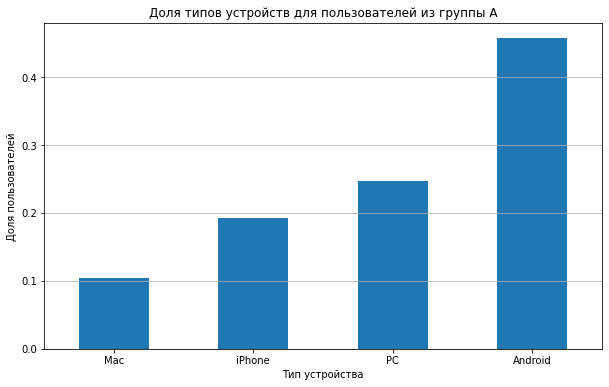

In [28]:
device_share_a.sort_values().plot(
    kind='bar',
    title='Доля типов устройств для пользователей из группы А',
    ylabel='Доля пользователей',
    xlabel='Тип устройства',
    rot=0,
    figsize=(10, 6)
)

plt.grid(axis='y')
plt.show()

In [29]:
device_share_b = ab_test_events_7days[ab_test_events_7days['group'] == 'B'].groupby('device')['user_id'].nunique()
device_share_b = device_share_b / device_share_b.sum()

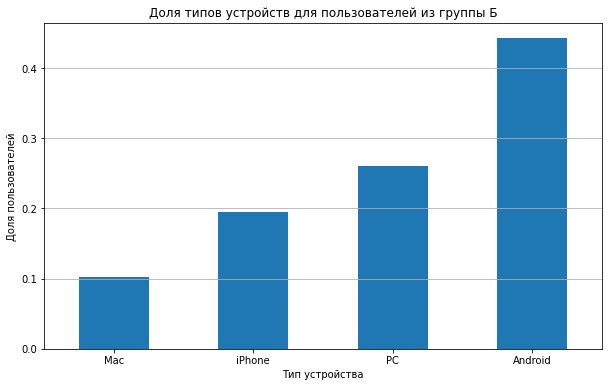

In [30]:
device_share_b.sort_values().plot(
    kind='bar',
    title='Доля типов устройств для пользователей из группы Б',
    ylabel='Доля пользователей',
    xlabel='Тип устройства',
    rot=0,
    figsize=(10, 6)
)

plt.grid(axis='y')
plt.show()

**Предварительные выводы по группам**

1. **Размер групп:** A — 4952 пользователя, B — 5011; разница 1,19%. Обе группы больше необходимого размера выборки (3761 на группу).
2. **Устройства:** структура близка: Android около 45%, PC около 25%, iPhone около 19%, Mac около 10%; различия в пределах 1–2 п.п.
3. **Конверсия в покупку за 7 дней:**
   - A: 1377 покупателей, $CR_A = 27,81\%$;
   - B: 1480 покупателей, $CR_B = 29,54\%$;
   - разница +1,73 п.п. (около +6,2% относительно группы A); покупателей в группе B на 7,48% больше, но и сама группа немного больше.
   - Ожидаемый эффект +3 п.п. не достигнут.

Далее проверим, статистически значима ли разница.

## 4. Статистическая оценка результатов

**Метод:** двусторонний z-тест для разности двух долей.

**Гипотезы:**
* $H_0$: конверсия в покупку за 7 дней после регистрации в группах A и B одинакова ($p_A = p_B$).
* $H_1$: конверсии различаются ($p_A \ne p_B$).

**Параметры:**
* уровень значимости $\alpha = 0.05$;
* метрика — доля пользователей группы, совершивших `purchase` в течение 7 дней после регистрации;
* если p-value < $\alpha$, $H_0$ отвергается.

In [31]:
from statsmodels.stats.proportion import proportions_ztest

# Уникальные пользователи в группах (знаменатель)
n_a = ab_test_participants[ab_test_participants['group'] == 'A'][
    'user_id'
].nunique()
n_b = ab_test_participants[ab_test_participants['group'] == 'B'][
    'user_id'
].nunique()

# Уникальные покупатели за 7 дней (числитель)
m_a = ab_test_events_7days[
    (ab_test_events_7days['group'] == 'A')
    & (ab_test_events_7days['event_name'] == 'purchase')
]['user_id'].nunique()
m_b = ab_test_events_7days[
    (ab_test_events_7days['group'] == 'B')
    & (ab_test_events_7days['event_name'] == 'purchase')
]['user_id'].nunique()

p_a, p_b = m_a/n_a, m_b/n_b # Доли успехов для каждой группы: A и B

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10): # Проверка предпосылки о достаточном количестве данных
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

alpha = 0.05 # Уровень значимости


stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative= 'two-sided'
)

print(f'pvalue={p_value_ztest:.3f}')

if p_value_ztest < alpha:
    print(f'Результат: Нулевая гипотеза отвергается! Различие в конверсии между группами A и B статистически значимо.')
else:
    print(f'Результат: Нулевая гипотеза не отвергается! Различие в конверсии статистически не значимо.')

Предпосылка о достаточном количестве данных выполняется!
pvalue=0.057
Результат: Нулевая гипотеза не отвергается! Различие в конверсии статистически не значимо.


### Итоговые выводы по A/B-тесту

1. **Корректность:**
   - исключены 887 пользователей, участвовавших в параллельном тесте `recommender_system_test`;
   - пересечений между группами A и B нет;
   - группы сбалансированы (4952 и 5011, разница 1,19%) и больше необходимого размера (3761 на группу при $\alpha = 0.05$, мощности 80% и MDE 3 п.п.);
   - структура по устройствам в группах близка.

2. **Результат:**
   - конверсия за 7 дней: A — 27,81% (1377 покупателей из 4952), B — 29,54% (1480 из 5011);
   - двусторонний z-тест: p-value = 0,057 > 0,05, разница статистически незначима на уровне 5%.
   - Если проверять одностороннюю гипотезу «в группе B конверсия выше», p-value был бы примерно вдвое меньше (около 0,03) и разница стала бы значимой; такой расчёт в ноутбуке не выполнялся. Но и в этом случае наблюдаемый эффект меньше целевого.

3. **Достигнут ли ожидаемый эффект:** нет. Прирост +1,73 п.п. (около +6,2% относительно A) меньше целевых +3 п.п., под которые рассчитывался тест.

4. **Рекомендации:**
   - раскатывать новый интерфейс на всех пользователей в текущем виде не стоит: целевой прирост не достигнут, а значимость на границе;
   - изучить воронку и UX (на каком шаге пользователи уходят), доработать интерфейс и провести повторный тест.